In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.calibration import calibration_curve
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV, train_test_split
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    classification_report,
    confusion_matrix
)
import warnings
warnings.filterwarnings("ignore")

encoder = OneHotEncoder(handle_unknown='ignore')
import warnings
warnings.filterwarnings("ignore")

# pd.set_option("display.width", 150)
# pd.set_option("display.precision", 3)
# plt.rcParams["figure.figsize"] = (9, 4.2)
# plt.rcParams["axes.grid"] = True
# plt.rcParams["grid.alpha"] = 0.3
# plt.rcParams["figure.dpi"] = 110

SEED = 42

In [2]:
df = pd.read_csv("online_shoppers_intention.csv")
df.head(10)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.4,Feb,2,4,3,3,Returning_Visitor,False,False
7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,2,1,5,Returning_Visitor,True,False
8,0,0.0,0,0.0,2,37.000000,0.000000,0.100000,0.0,0.8,Feb,2,2,2,3,Returning_Visitor,False,False
9,0,0.0,0,0.0,3,738.000000,0.000000,0.022222,0.0,0.4,Feb,2,4,1,2,Returning_Visitor,False,False


In [5]:
df.shape

(12330, 18)

In [3]:
target_feature = 'Revenue'

categ_features = [
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Month",
    "Weekend"
]

quant_features = [
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'SpecialDay'
]

print(set(categ_features + quant_features + [target_feature]) == set(df.columns.to_list()) and len(categ_features) + len(quant_features) + 1 == len(df.columns.to_list()))

True


In [4]:
X = df.drop(columns=[target_feature])
y = df[target_feature]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, shuffle=True, stratify=y)

In [6]:
df_train = pd.concat([X_train, y_train], axis=1)

# EDA

## Первичная обработка

In [7]:
print('Все колонки:', df_train.columns.tolist())
df_train.info()

Все колонки: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']
<class 'pandas.core.frame.DataFrame'>
Index: 9864 entries, 4263 to 11430
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           9864 non-null   int64  
 1   Administrative_Duration  9864 non-null   float64
 2   Informational            9864 non-null   int64  
 3   Informational_Duration   9864 non-null   float64
 4   ProductRelated           9864 non-null   int64  
 5   ProductRelated_Duration  9864 non-null   float64
 6   BounceRates              9864 non-null   float64
 7   ExitRates                9864 non-null   float64
 8   PageValues               9864 non-null   flo

In [8]:
print('Пропусков по столбцам')
print(f'{df_train.isnull().sum()}')

Пропусков по столбцам
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [9]:
total_duplicates = df_train.duplicated().sum()
print(f"Всего дублирующихся строк: {total_duplicates}")
print(f"Процент от выборки {(total_duplicates / df_train.shape[0] * 100):.2f}%")
# df.drop_duplicates(inplace=True)

Всего дублирующихся строк: 91
Процент от выборки 0.92%


In [10]:
df_train.drop_duplicates(inplace=True)

## Распределение

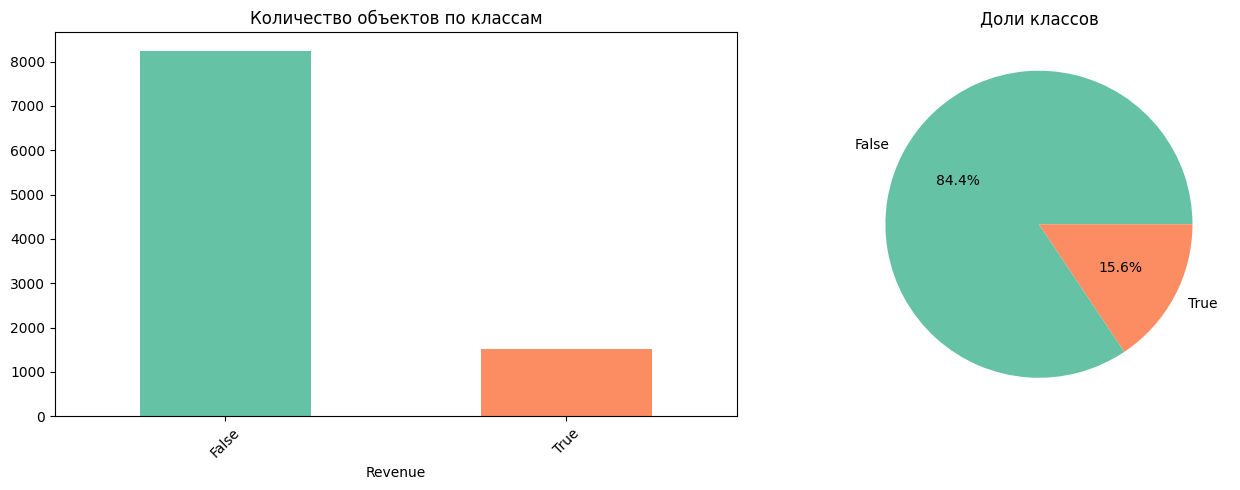

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_train[target_feature].value_counts().plot.bar(ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('Количество объектов по классам')
axes[0].tick_params(axis='x', rotation=45)

df_train[target_feature].value_counts(normalize=True).plot.pie(ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_ylabel('')
axes[1].set_title('Доли классов')
plt.tight_layout()
plt.show()

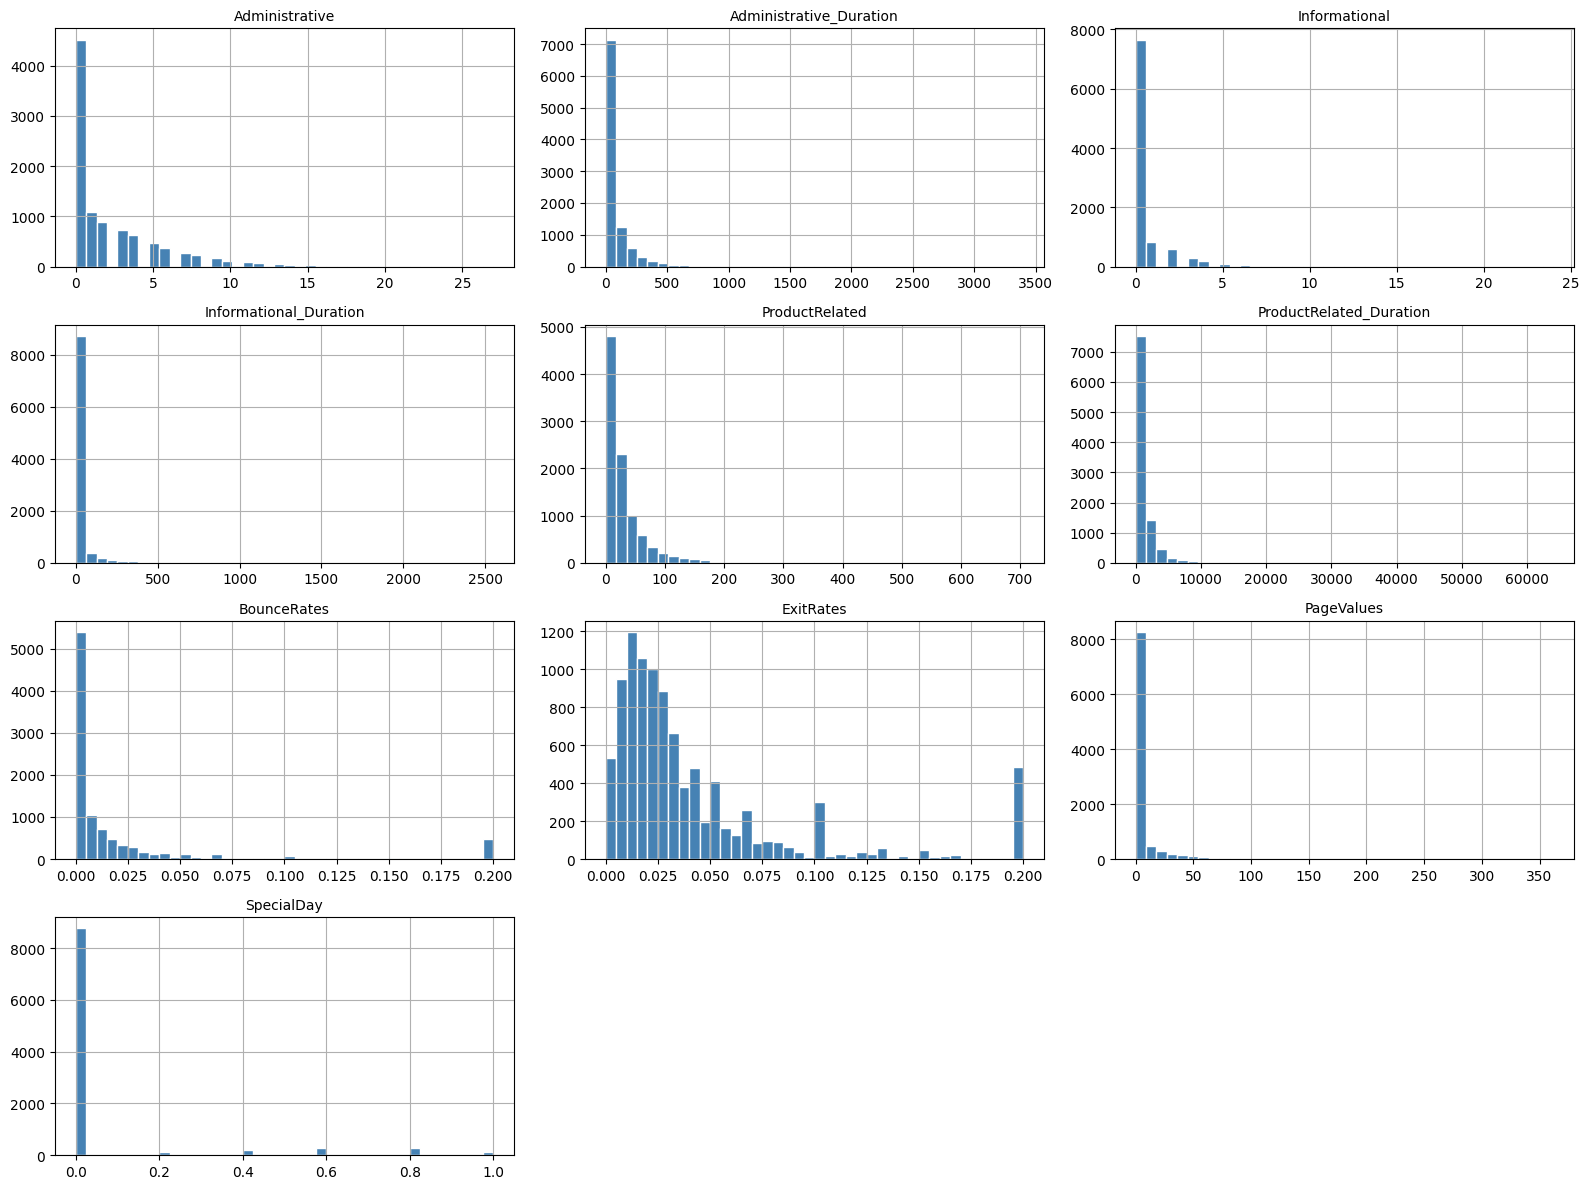

In [12]:
n_cols = len(quant_features)
n_rows = (n_cols + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(quant_features):
    df_train[col].hist(bins=40, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

for j in range(len(quant_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [13]:
df_train[list(quant_features)].describe(percentiles=[.05, .25, .50, .75, .95, .99]).T

,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
Administrative,9773.0,2.339200,3.326984,0.0,0.000000,0.000000,1.000000,4.000000,9.000000,14.000000,27.000000
Administrative_Duration,9773.0,81.997525,180.272802,0.0,0.000000,0.000000,9.166667,94.233333,352.161429,870.800000,3398.750000
Informational,9773.0,0.509363,1.280158,0.0,0.000000,0.000000,0.000000,0.000000,3.000000,6.000000,24.000000
Informational_Duration,9773.0,34.912334,142.046383,0.0,0.000000,0.000000,0.000000,0.000000,197.200000,722.934400,2549.375000
ProductRelated,9773.0,31.735803,43.718829,0.0,2.000000,8.000000,18.000000,38.000000,109.000000,211.560000,705.000000
ProductRelated_Duration,9773.0,1197.594376,1914.668948,0.0,0.000000,190.750000,611.000000,1484.000000,4252.911417,8601.314432,63973.522230
BounceRates,9773.0,0.020742,0.045913,0.0,0.000000,0.000000,0.002930,0.016667,0.160000,0.200000,0.200000
ExitRates,9773.0,0.041854,0.046721,0.0,0.004584,0.014283,0.025000,0.049397,0.187556,0.200000,0.200000
PageValues,9773.0,5.999914,18.639490,0.0,0.000000,0.000000,0.000000,0.000000,39.422226,85.856643,361.763742
SpecialDay,9773.0,0.063195,0.201978,0.0,0.000000,0.000000,0.000000,0.000000,0.600000,1.000000,1.000000


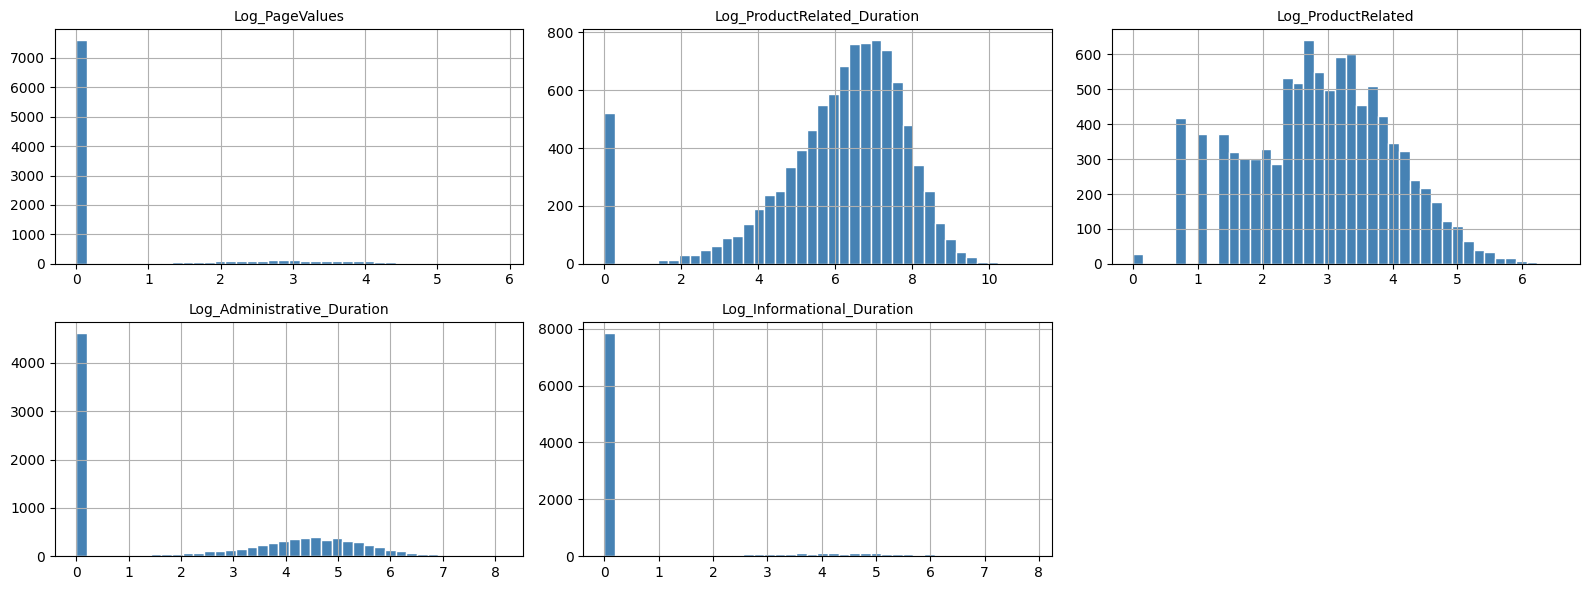

In [14]:
log_features = [
   'PageValues',
   'ProductRelated_Duration',
   'ProductRelated',
   'Administrative_Duration',
   'Informational_Duration',
]

n_cols = len(log_features)
n_rows = (n_cols + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(log_features):
    np.log1p(df_train[col]).hist(bins=40, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title('Log_' + col, fontsize=10)

for j in range(len(log_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

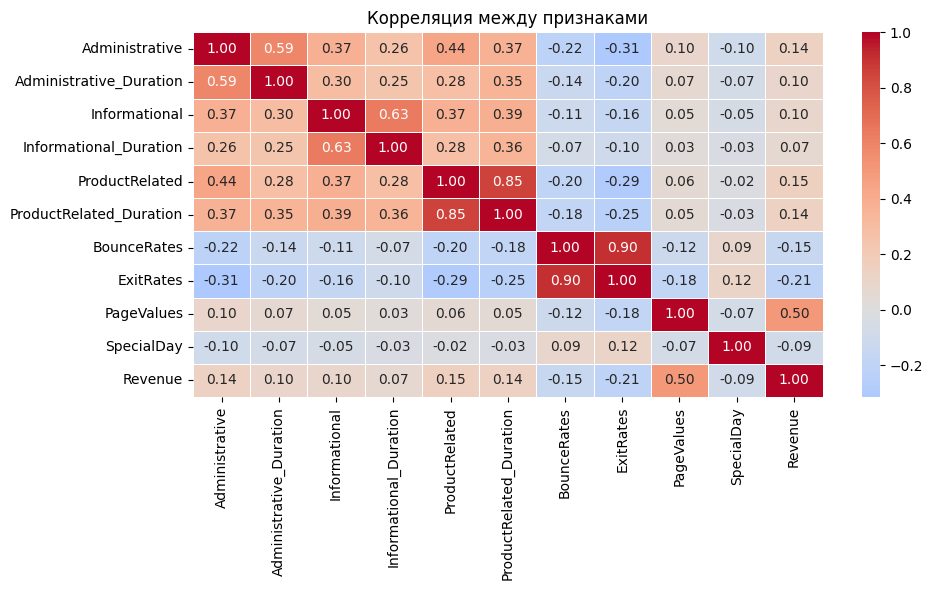

In [15]:
plt.figure(figsize=(10, 6))
corr = df_train[quant_features + [target_feature]].corr()
# mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляция между признаками')
plt.tight_layout()
plt.show()

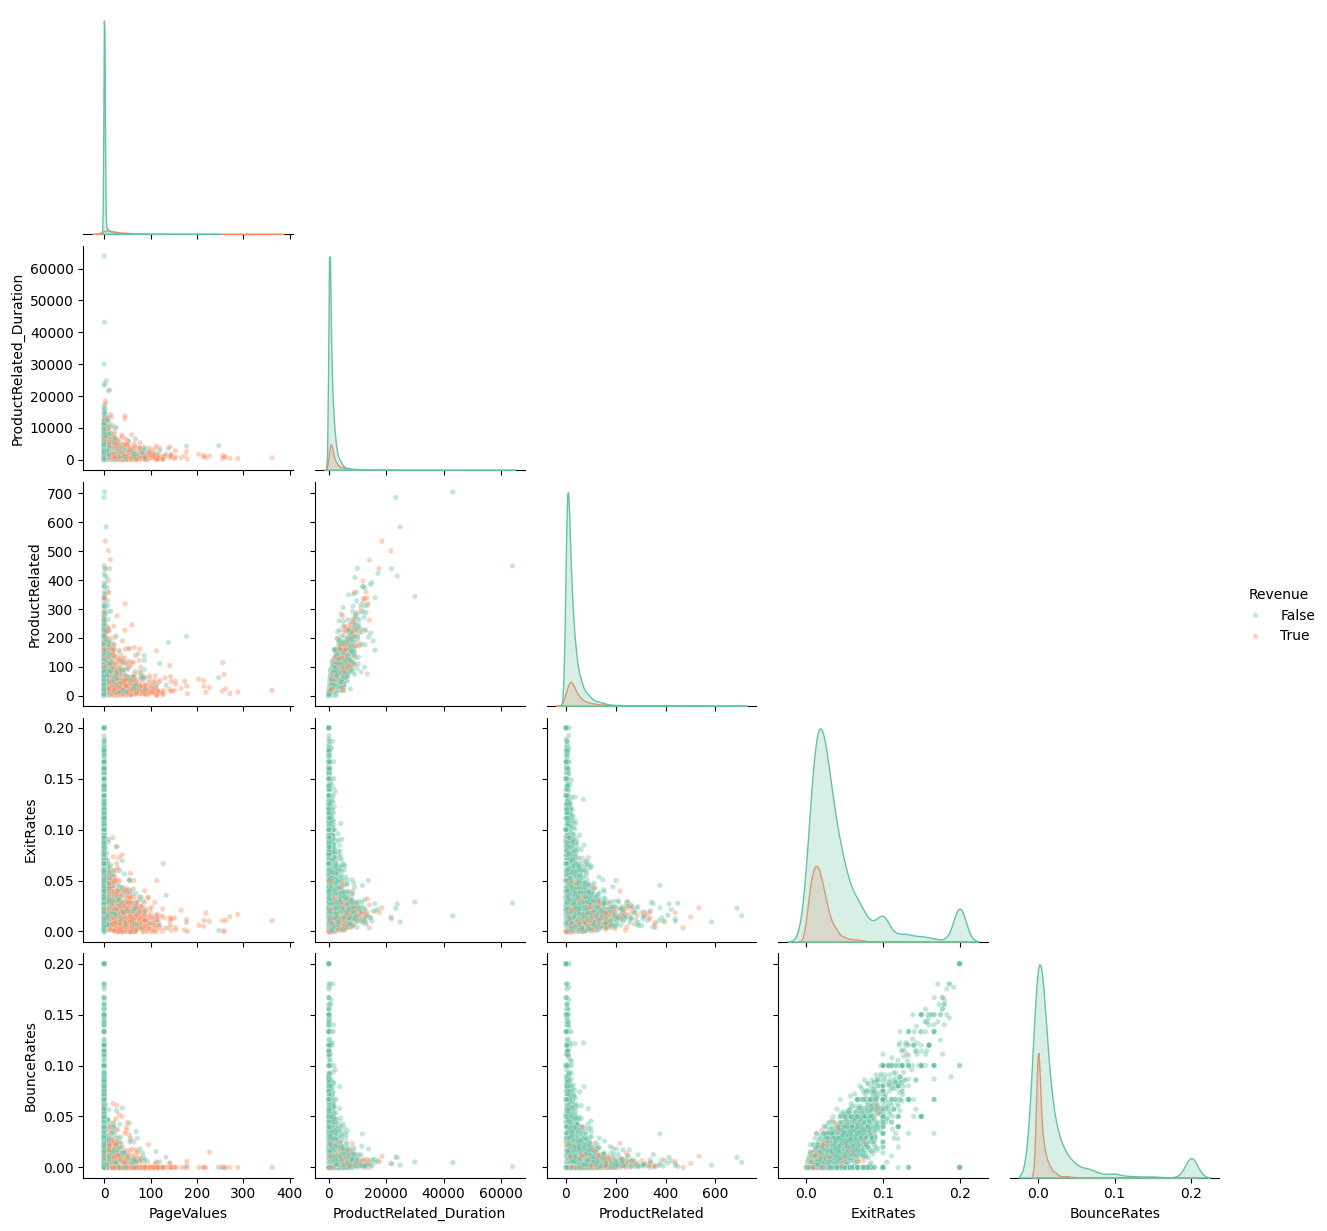

In [16]:
sns.pairplot(
    df_train[
        [
            'PageValues',
            'ProductRelated_Duration',
            'ProductRelated',
            'ExitRates',
            'BounceRates',
            'Revenue'
        ]
    ],
    hue='Revenue',
    corner=True,
    palette='Set2',
    plot_kws={'alpha': 0.4, 's': 15}
)

## Категориальные фичи

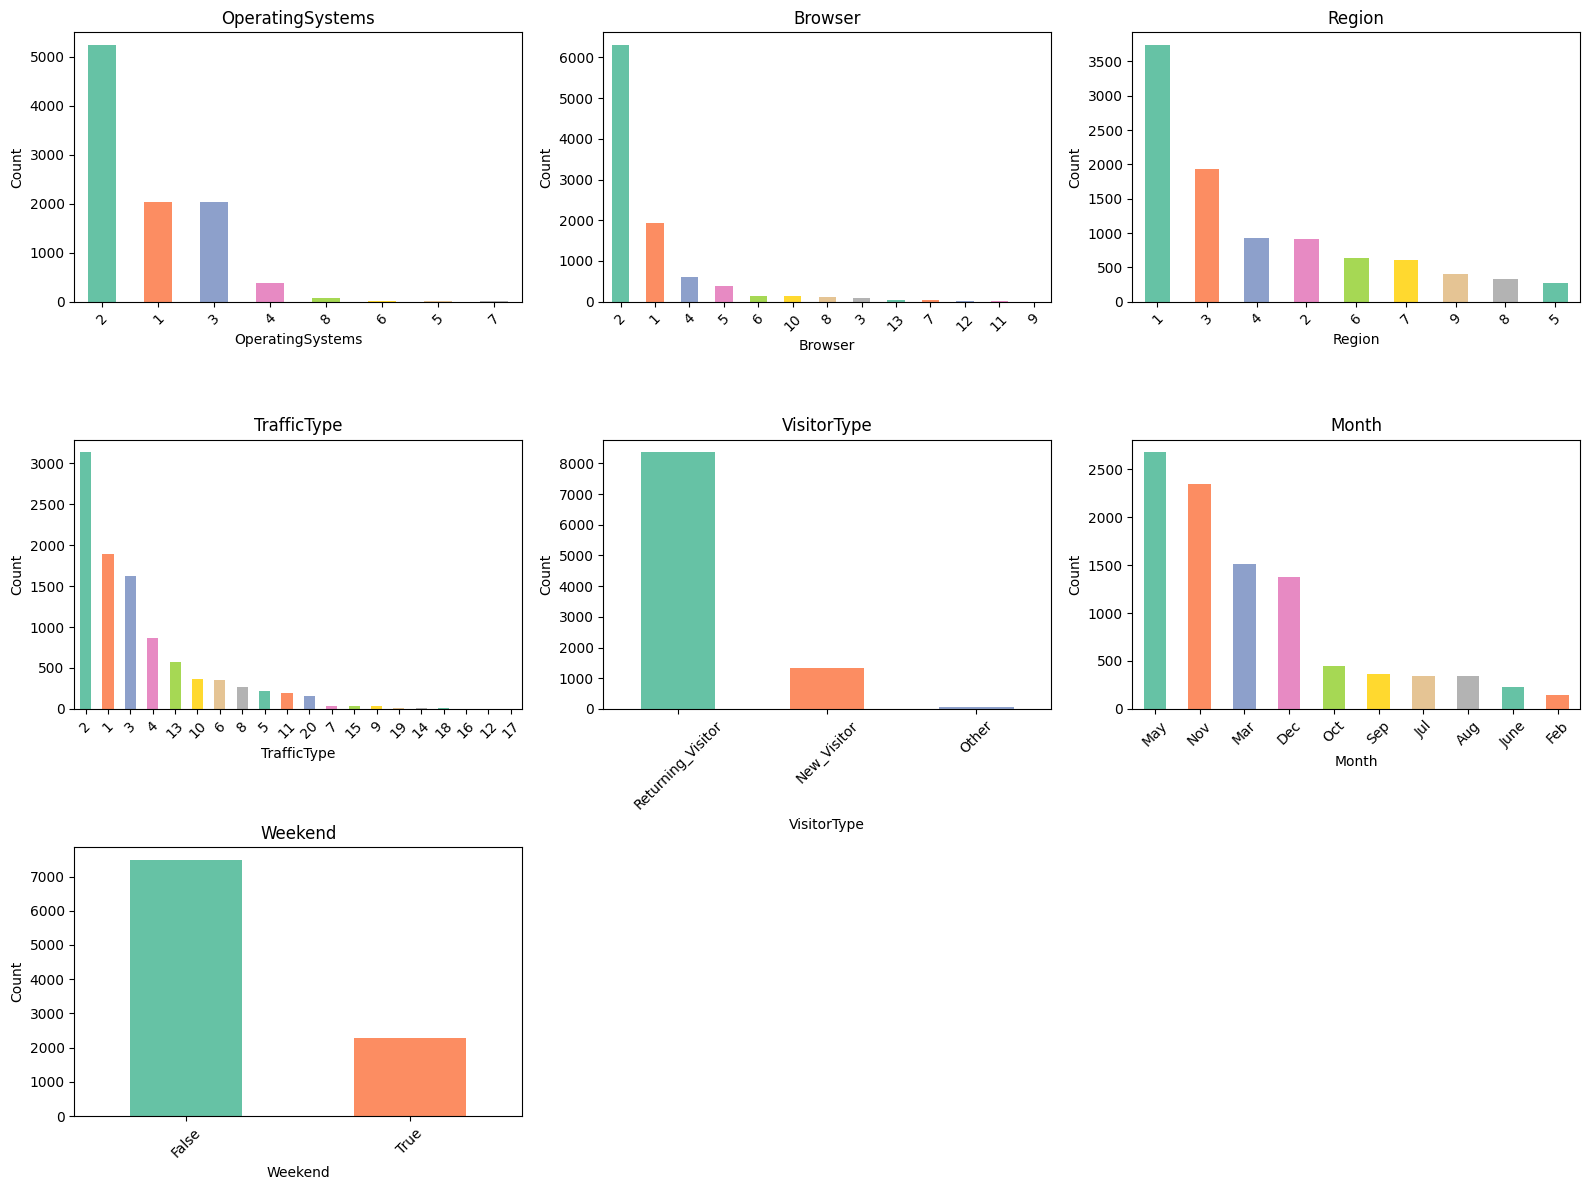

In [17]:
n_cols = 3
n_rows = (len(categ_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(categ_features):
    df_train[col].value_counts().plot.bar(ax=axes[i], color=sns.color_palette('Set2'))
    axes[i].set_title(col, fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Count')

for j in range(len(categ_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

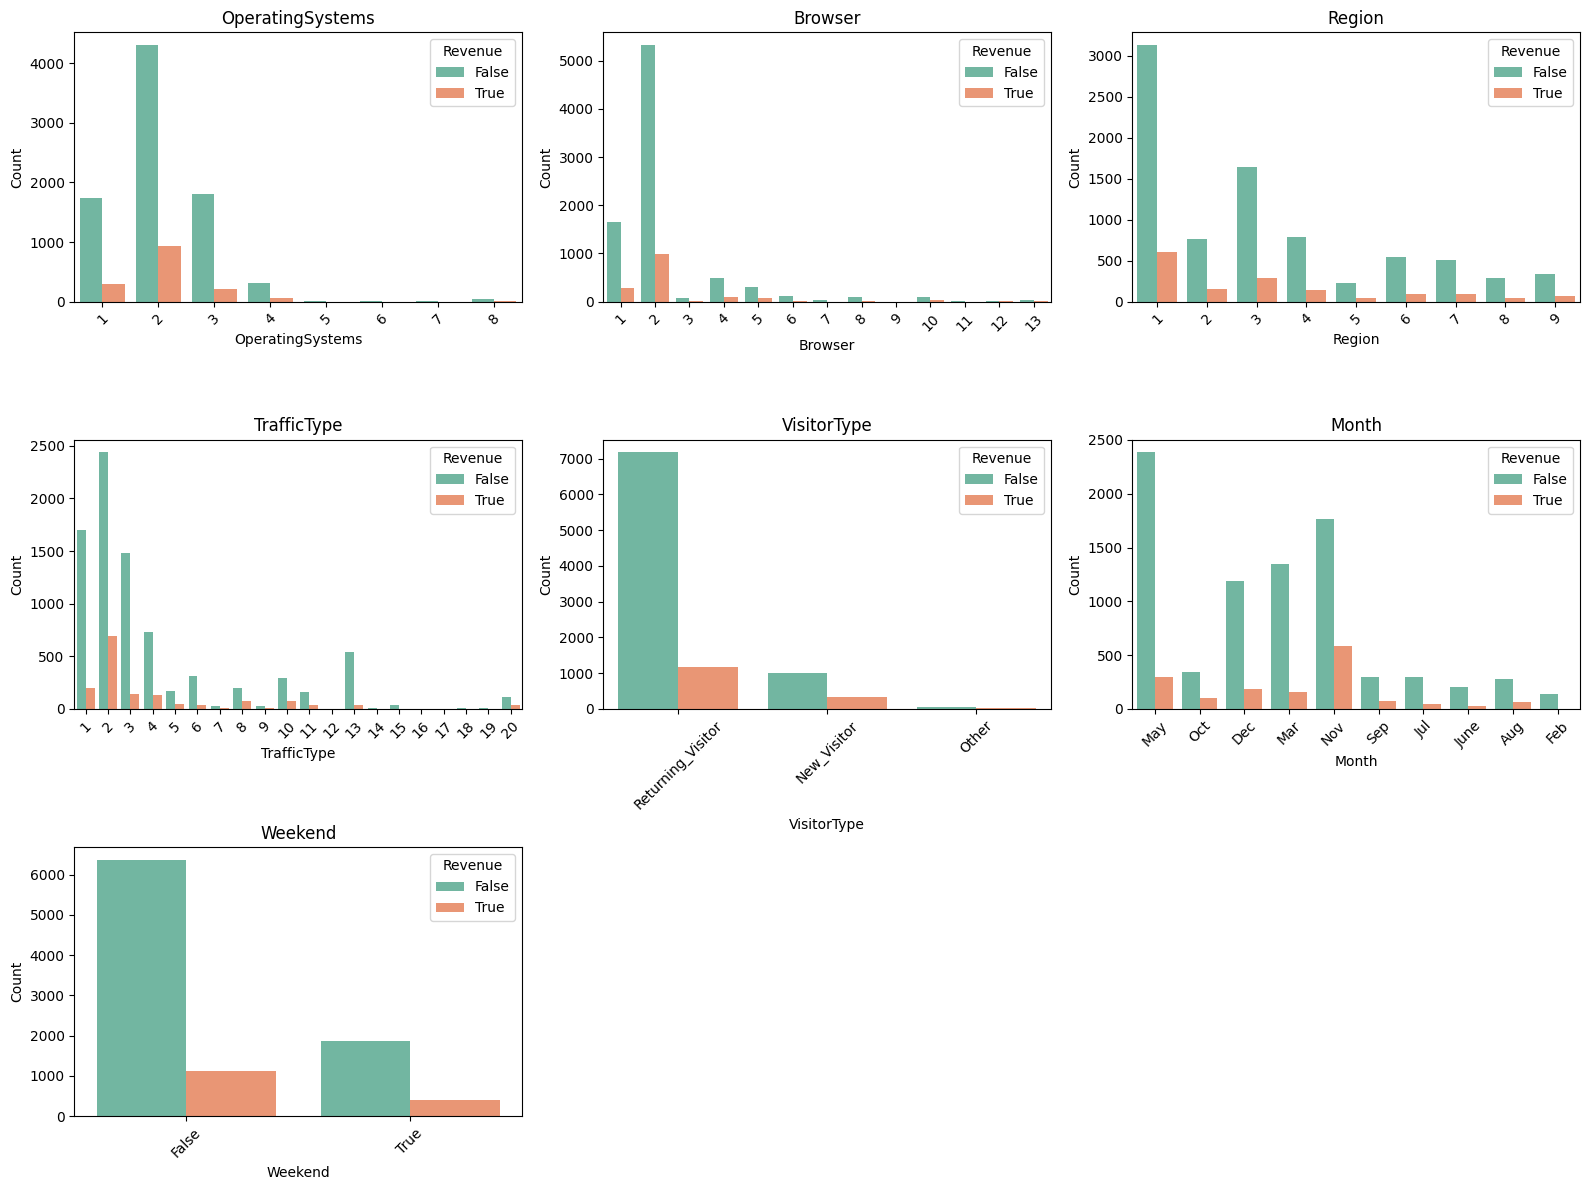

In [18]:
n_cols = 3
n_rows = (len(categ_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(categ_features):
    sns.countplot(data=df_train, x=col, hue=target_feature, ax=axes[i], palette='Set2')
    axes[i].set_title(col, fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Count')
    axes[i].legend(title=target_feature)

for j in range(len(categ_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Feature engineering

## Функция для оценки классификационной модели

Создадим функцию `evaluate_classification_model`, которая будет принимать тестовые данные (`y_test`), предсказанные классы (`y_pred`) и предсказанные вероятности (`y_prob`). Эта функция будет выводить:

- Отчет о классификации (precision, recall, f1-score, support).
- Матрицу ошибок (Confusion Matrix).
- ROC-кривую и PR-кривую.
- Калибровочную кривую и распределение предсказанных вероятностей.
- График зависимости Precision, Recall и F1-меры от порога принятия решения.

In [50]:
def evaluate_classification_model(y_test, thresh, y_prob, model_name="Model"):
    """
    Выводит отчет о классификации, матрицу ошибок, ROC- и PR-кривые,
    калибровочную кривую и зависимость метрик от порога.
    """
    y_pred = (y_prob >= thresh).astype(int)
    print(f"### Отчет о классификации для {model_name}:\n")
    print(classification_report(y_test, y_pred))
    print(f"### ROC-AUC для {model_name}: {roc_auc_score(y_test, y_prob)}")
    print(f"### PR-AUC для {model_name}: {average_precision_score(y_test, y_prob)}")

    print(f"\n### Матрица ошибок для {model_name}:\n")
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Предсказанные')
    plt.ylabel('Фактические')
    plt.title(f'Матрица ошибок для {model_name}')
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ROC-кривая
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, linewidth=2, label=f'{model_name} (AUC={roc_auc:.3f})')
    axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC=0.5)')
    axes[0].set_xlabel('FPR')
    axes[0].set_ylabel('TPR')
    axes[0].set_title(f'ROC-кривая для {model_name}')
    axes[0].legend()

    # PR-кривая
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    axes[1].plot(rec, prec, linewidth=2, label=f'{model_name} (AP={ap:.3f})')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title(f'PR-кривая для {model_name}')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # Калибровочная кривая и распределение вероятностей
    prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot([0, 1], [0, 1], 'k--', label='Идеальная калибровка')
    axes[0].plot(prob_pred, prob_true, 'o-', label=model_name)
    axes[0].set_xlabel('Средняя предсказанная вероятность'); axes[0].set_ylabel('Доля положительных')
    axes[0].set_title(f'Калибровочная кривая для {model_name}'); axes[0].legend()
    axes[1].hist(y_prob, bins=30, color='steelblue', edgecolor='white')
    axes[1].set_xlabel('Предсказанная вероятность P(y=1)'); axes[1].set_ylabel('Количество')
    axes[1].set_title(f'Распределение предсказанных вероятностей для {model_name}')
    plt.tight_layout(); plt.show()

    # Precision, Recall, F1 в зависимости от порога
    thresholds = np.arange(0.05, 0.95, 0.05)
    df_t = pd.DataFrame(columns=['threshold', 'precision', 'recall', 'f1'])

    for threshold in thresholds:
        y_pred_thresh = (y_prob >= threshold).astype(int)
        precision = precision_score(y_test, y_pred_thresh, zero_division=0)
        recall = recall_score(y_test, y_pred_thresh, zero_division=0)
        f1 = f1_score(y_test, y_pred_thresh, zero_division=0)

        new_row = pd.DataFrame([
            {
                'threshold': threshold,
                'precision': precision,
                'recall': recall,
                'f1': f1
            }
        ])
        df_t = pd.concat([df_t, new_row], ignore_index=True)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(df_t['threshold'], df_t['precision'], 'o-', label='Precision')
    ax.plot(df_t['threshold'], df_t['recall'], 's-', label='Recall')
    ax.plot(df_t['threshold'], df_t['f1'], '^-', label='F1')
    ax.set_xlabel('Порог τ')
    ax.set_ylabel('Значение метрики')
    ax.set_title(f'Precision / Recall / F1 при разных порогах для {model_name}')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [43]:
def find_best_threshold(y_test, y_prob):
  tresholds = np.arange(0.05, 0.95, 0.05)
  f1_scores = []

  for treshold in tresholds:
    y_pred = (y_prob >= treshold).astype(int)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    f1_scores.append(f1)

  best_treshold_idx = np.argmax(f1_scores)
  best_treshold = tresholds[best_treshold_idx]
  return best_treshold.item()

In [71]:
def group_rare_categories(df, features, threshold=10):
    df_copy = df.copy()
    for col in features:
      if df_copy[col].dtype == bool:
        continue
        # Convert to string to handle mixed types and then replace
      df_copy[col] = df_copy[col].astype(str)
      counts = df_copy[col].value_counts()
      rare_categories = counts[counts < threshold].index
      df_copy[col] = df_copy[col].replace(rare_categories, 'Other')
    return df_copy


In [19]:
X_train = df_train.drop(columns=[target_feature])
y_train = df_train[target_feature]

In [72]:
X_train_processed = group_rare_categories(X_train, categ_features)
X_test_processed = group_rare_categories(X_test, categ_features)

# Эксперименты

In [22]:
from sklearn.linear_model import LogisticRegression

## Логарифмирование признаков

In [20]:
quant_without_log = [f for f in quant_features if f not in log_features]

log_transformer = Pipeline([
    ("log", FunctionTransformer(np.log1p, validate=False)),
    ("scaler", StandardScaler())
])

num_transformer = Pipeline([
    ("scaler", StandardScaler())
])

preprocessor_log = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            categ_features
        ),
        (
            "log",
            log_transformer,
            log_features
        ),
        (
            "num",
            num_transformer,
            quant_without_log
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            categ_features
        ),
        (
            "num",
            num_transformer,
            quant_features
        )
    ]
)

param_grid = [
    {
        "classifier__solver": ["liblinear"],
        "classifier__penalty": ["l1", "l2"],
        "classifier__C": [0.01, 0.1, 1, 10, 100],
        "classifier__class_weight": [None, "balanced"]
    },
    {
        "classifier__solver": ["lbfgs"],
        "classifier__penalty": ["l2"],
        "classifier__C": [0.01, 0.1, 1, 10, 100],
        "classifier__class_weight": [None, "balanced"]
    }
]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [23]:
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        random_state=42,
        max_iter=3000
    ))
])

pipe_log = Pipeline([
    ("preprocessor", preprocessor_log),
    ("classifier", LogisticRegression(
        random_state=42,
        max_iter=3000
    ))
])

In [76]:
grid_no_log = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True
)

grid_log = GridSearchCV(
    estimator=pipe_log,
    param_grid=param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True
)

grid_no_log.fit(X_train_processed, y_train)
grid_log.fit(X_train_processed, y_train)

print(grid_no_log.best_score_)
print(grid_log.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
0.6570974709790517
0.6925030169343803


логарифмирование действительно улучшило результат

In [77]:
print(grid_no_log.best_params_)
print(grid_log.best_params_)

{'classifier__C': 0.1, 'classifier__class_weight': 'balanced'}
{'classifier__C': 0.1, 'classifier__class_weight': None}


### Сравнение моделей `grid_no_log` и `grid_log` на тестовой выборке

Оценка модели без логарифмирования (grid_no_log):
### Отчет о классификации для Logistic Regression (No Log Transform):

              precision    recall  f1-score   support

       False       0.94      0.90      0.92      2084
        True       0.56      0.70      0.62       382

    accuracy                           0.87      2466
   macro avg       0.75      0.80      0.77      2466
weighted avg       0.88      0.87      0.88      2466

### ROC-AUC для Logistic Regression (No Log Transform): 0.8957941835575967
### PR-AUC для Logistic Regression (No Log Transform): 0.6264672337740399

### Матрица ошибок для Logistic Regression (No Log Transform):



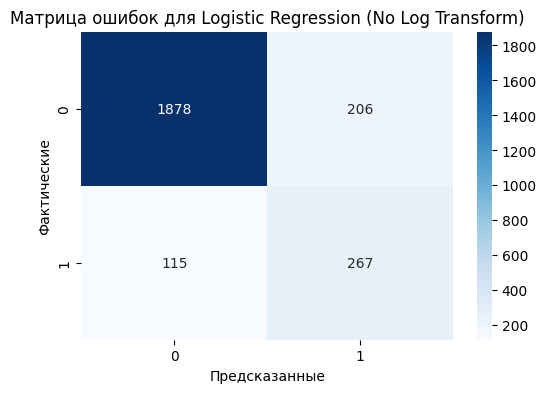

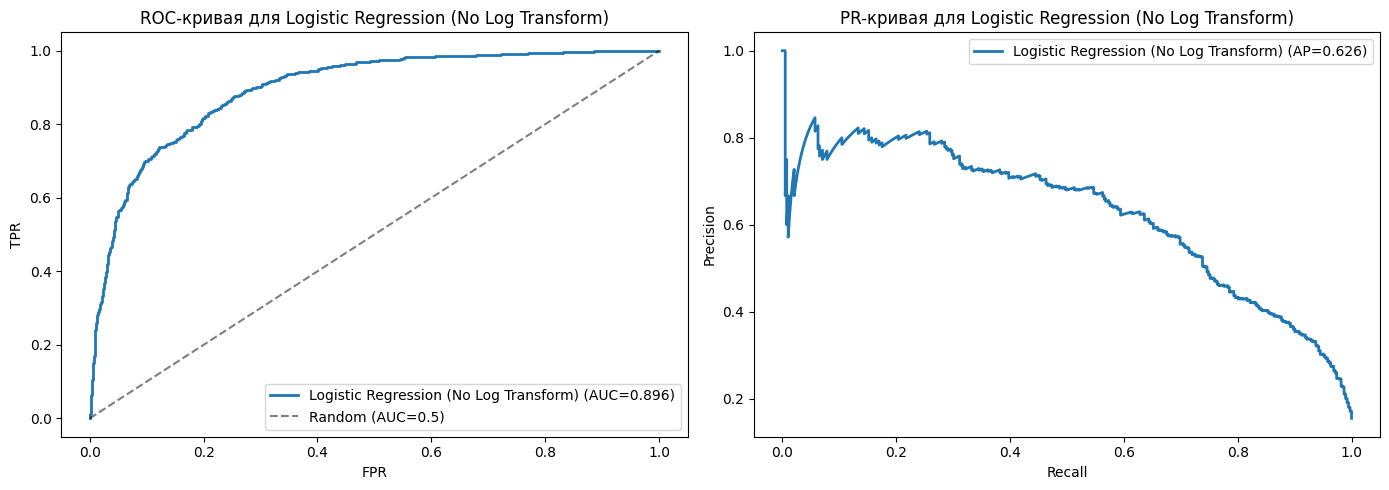

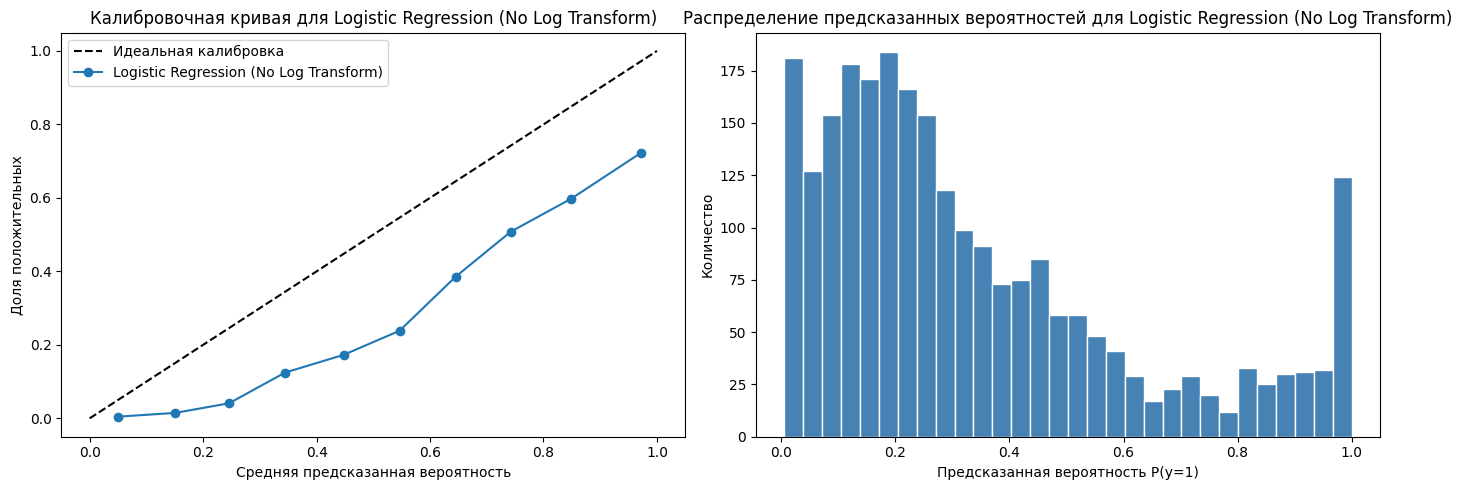

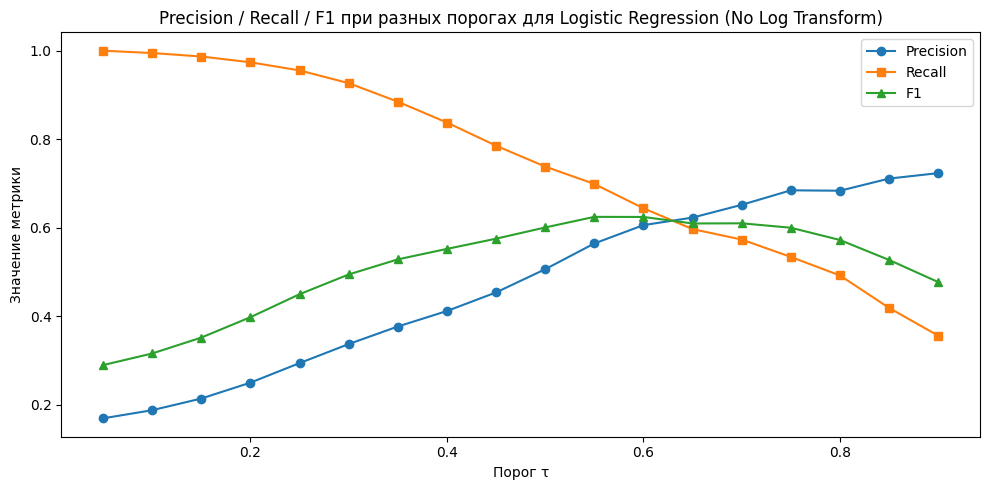

In [78]:
print('Оценка модели без логарифмирования (grid_no_log):')

evaluate_classification_model(
    y_test = y_test,
    thresh = find_best_threshold(y_test=y_test, y_prob=grid_no_log.best_estimator_.predict_proba(X_test_processed)[:, 1]),
    y_prob = grid_no_log.best_estimator_.predict_proba(X_test_processed)[:, 1],
    model_name="Logistic Regression (No Log Transform)"
)


Оценка модели с логарифмированием (grid_log):
### Отчет о классификации для Logistic Regression (Log Transform):

              precision    recall  f1-score   support

       False       0.95      0.90      0.93      2084
        True       0.58      0.74      0.65       382

    accuracy                           0.88      2466
   macro avg       0.77      0.82      0.79      2466
weighted avg       0.89      0.88      0.88      2466

### ROC-AUC для Logistic Regression (Log Transform): 0.9120285697058617
### PR-AUC для Logistic Regression (Log Transform): 0.6668763993851701

### Матрица ошибок для Logistic Regression (Log Transform):



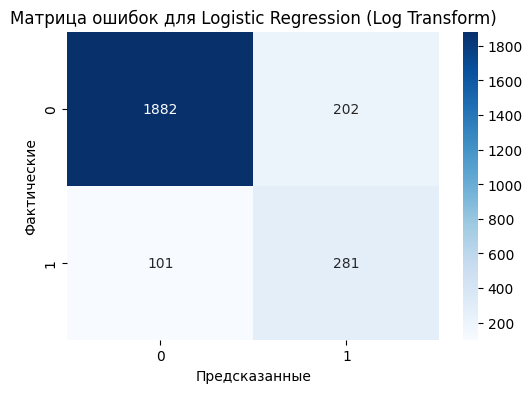

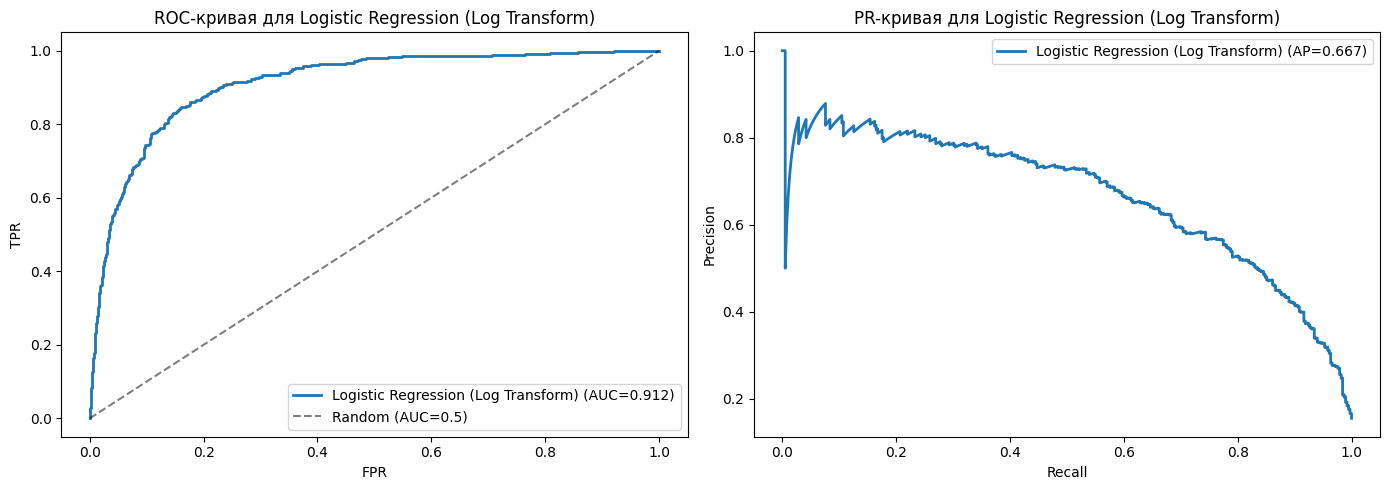

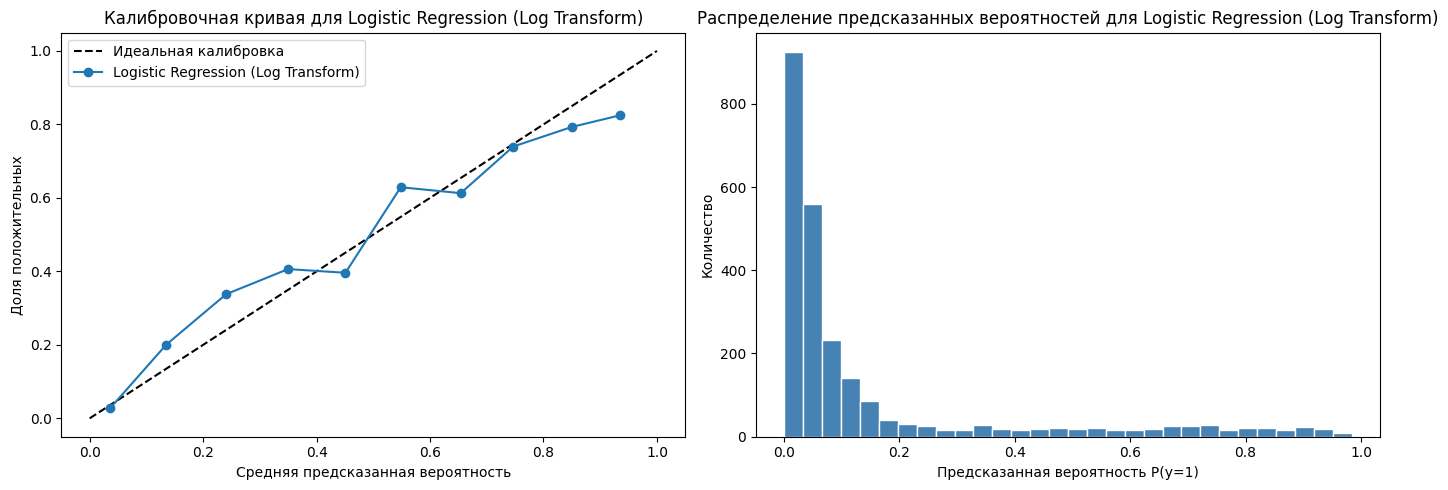

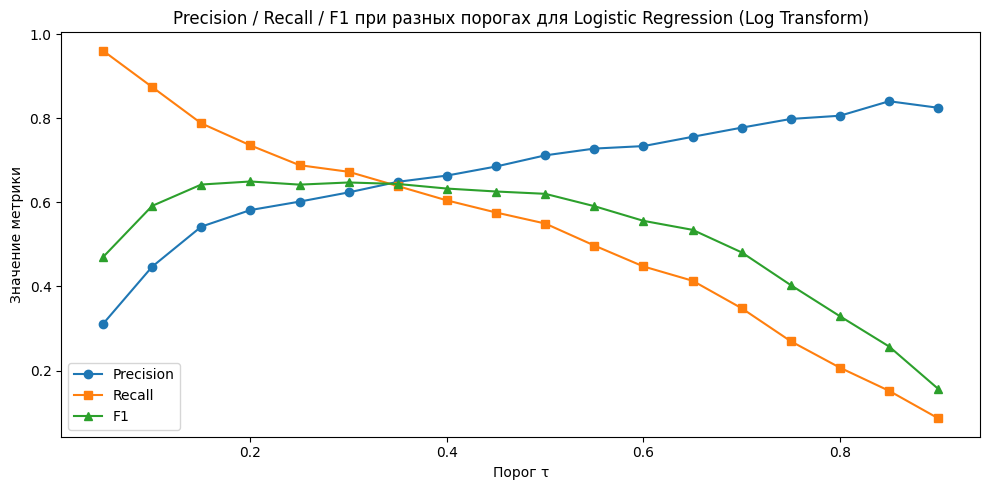

In [79]:
print('\nОценка модели с логарифмированием (grid_log):')

evaluate_classification_model(
    y_test = y_test,
    thresh = find_best_threshold(y_test=y_test, y_prob=grid_log.best_estimator_.predict_proba(X_test_processed)[:, 1]),
    y_prob = grid_log.best_estimator_.predict_proba(X_test_processed)[:, 1],
    model_name = "Logistic Regression (Log Transform)"
)

##  Ridge ∘ Lasso vs Ridge

In [80]:
quant_without_log = [f for f in quant_features if f not in log_features]

log_transformer = Pipeline([
    ("log", FunctionTransformer(np.log1p, validate=False, feature_names_out="one-to-one")),
    ("scaler", StandardScaler())
])

num_transformer = Pipeline([
    ("scaler", StandardScaler())
])

selection = SelectFromModel(
    LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=0.1,
        random_state=42,
        max_iter=3000
    )
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            categ_features
        ),
        (
            "log",
            log_transformer,
            log_features
        ),
        (
            "num",
            num_transformer,
            quant_without_log
        )
    ]
)


pipe_ridge_lasso = Pipeline([
    ("preprocessor", preprocessor),
    ("selection", selection),
    ("classifier", LogisticRegression(
        random_state=42,
        max_iter=3000,
        penalty='l2'
    ))
])

pipe_ridge = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        random_state=42,
        max_iter=3000,
        penalty='l2'
    ))
])

param_grid = [
    {
        "classifier__C": [0.01, 0.1, 1, 10, 100],
        "classifier__class_weight": [None, "balanced"]
    }
]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search_ridge_lasso = GridSearchCV(
    estimator=pipe_ridge_lasso,
    param_grid=param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True
)

grid_search_ridge = GridSearchCV(
    estimator=pipe_ridge,
    param_grid=param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True
)


grid_search_ridge_lasso.fit(X_train_processed, y_train)
grid_search_ridge.fit(X_train_processed, y_train)

print(grid_search_ridge_lasso.best_params_)
print(grid_search_ridge.best_params_)

print(grid_search_ridge_lasso.best_score_)
print(grid_search_ridge.best_score_)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'classifier__C': 0.1, 'classifier__class_weight': None}
{'classifier__C': 0.1, 'classifier__class_weight': None}
0.6932187591087191
0.6925030169343803


### Отчет о классификации для Ridge:

              precision    recall  f1-score   support

       False       0.95      0.90      0.93      2084
        True       0.58      0.74      0.65       382

    accuracy                           0.88      2466
   macro avg       0.77      0.82      0.79      2466
weighted avg       0.89      0.88      0.88      2466

### ROC-AUC для Ridge: 0.9120285697058617
### PR-AUC для Ridge: 0.6668763993851701

### Матрица ошибок для Ridge:



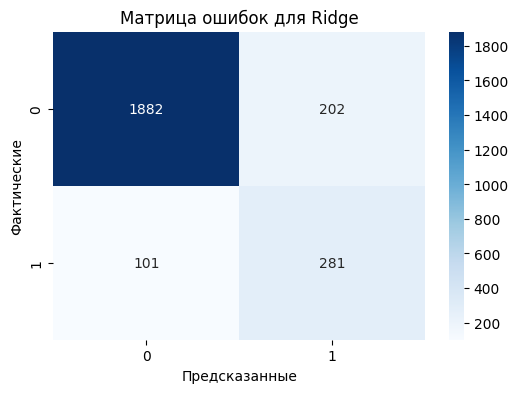

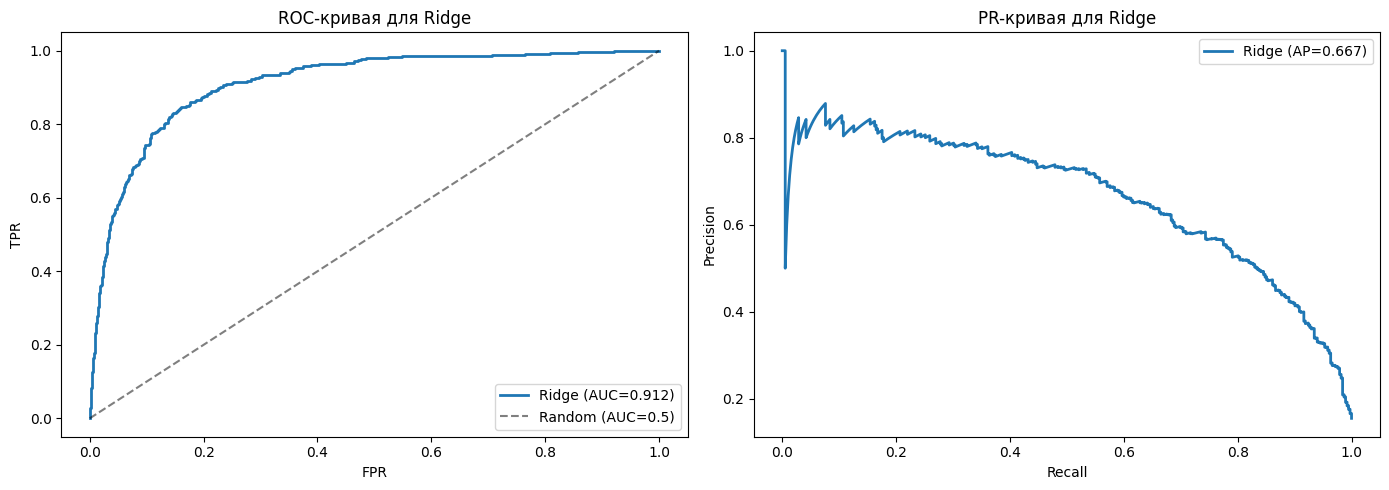

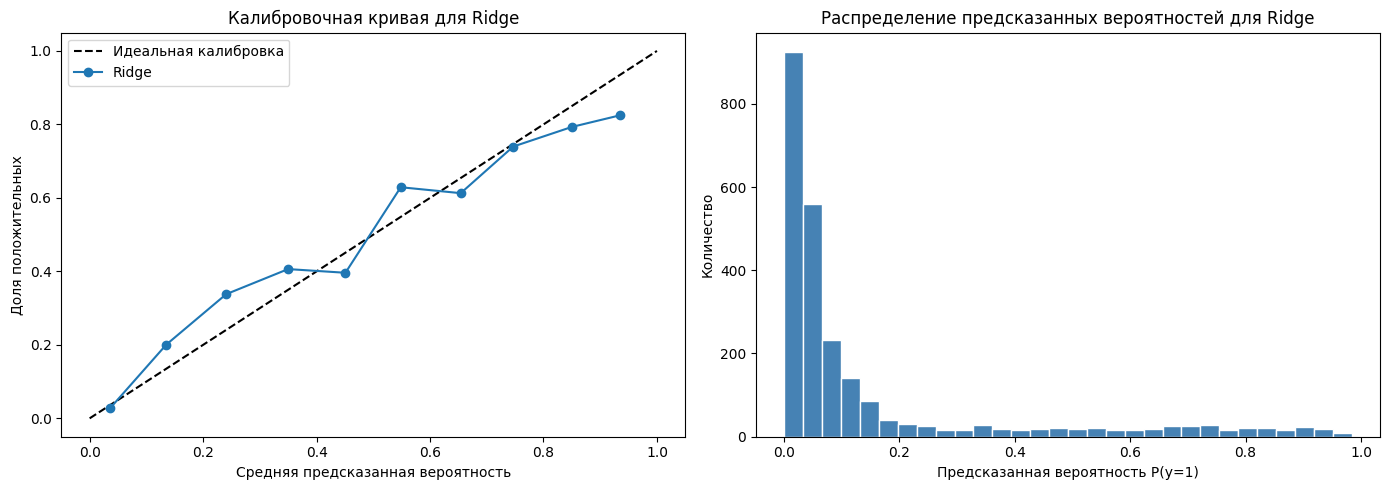

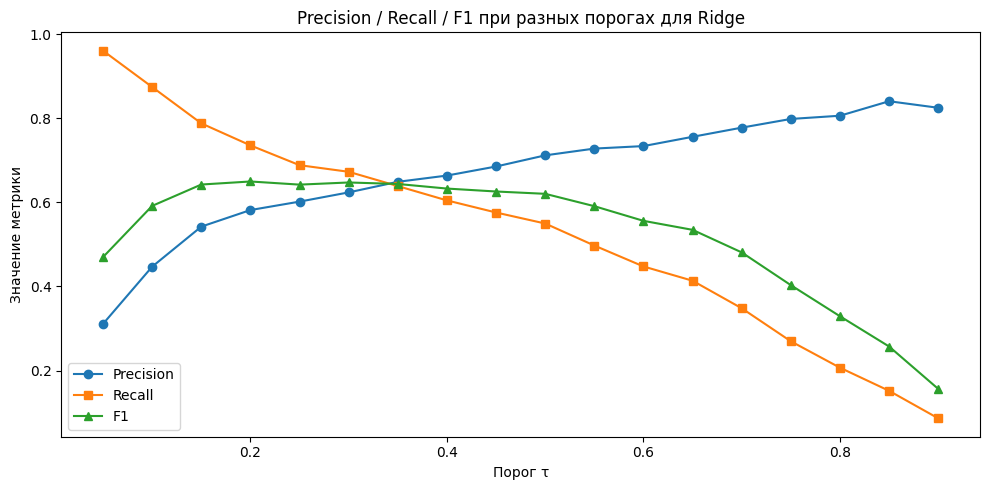

In [81]:
evaluate_classification_model(
    y_test=y_test,
    thresh=find_best_threshold(y_test=y_test, y_prob=grid_search_ridge.best_estimator_.predict_proba(X_test_processed)[:, 1]),
    y_prob=grid_search_ridge.best_estimator_.predict_proba(X_test_processed)[:, 1],
    model_name="Ridge"
)

### Отчет о классификации для Ridge + Lasso:

              precision    recall  f1-score   support

       False       0.94      0.94      0.94      2084
        True       0.65      0.65      0.65       382

    accuracy                           0.89      2466
   macro avg       0.79      0.79      0.79      2466
weighted avg       0.89      0.89      0.89      2466

### ROC-AUC для Ridge + Lasso: 0.9120386188461578
### PR-AUC для Ridge + Lasso: 0.668583718728403

### Матрица ошибок для Ridge + Lasso:



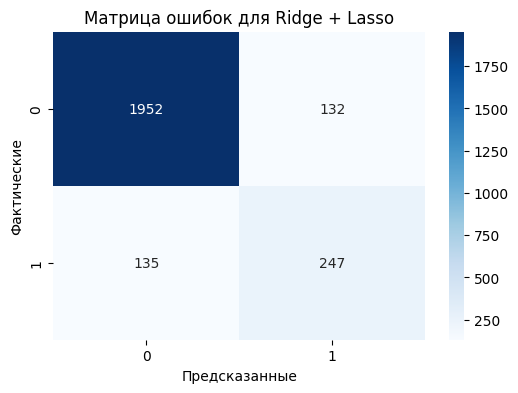

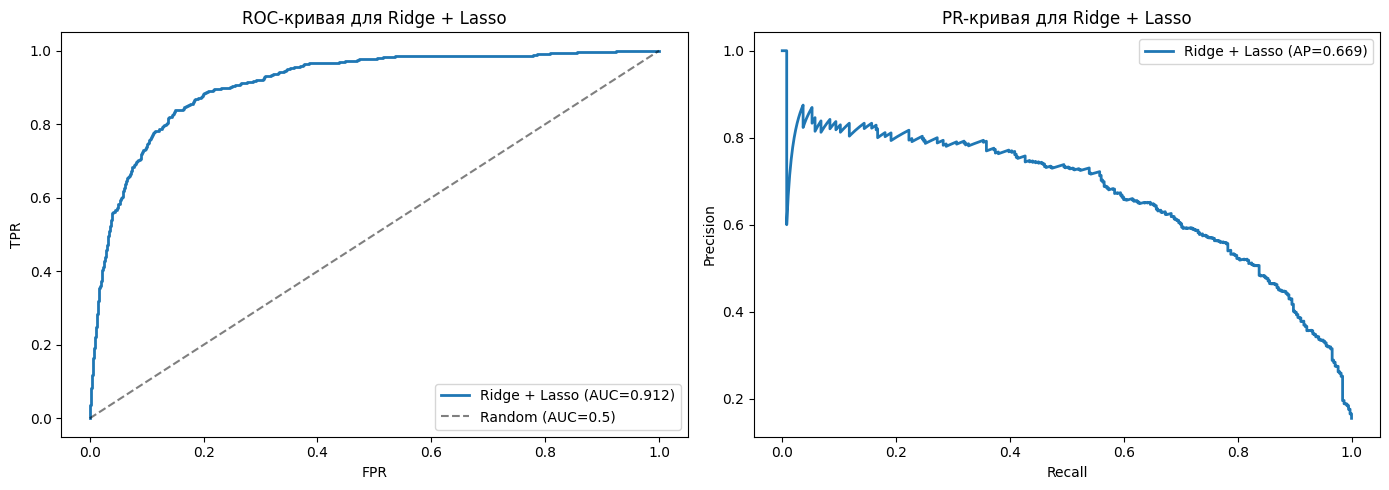

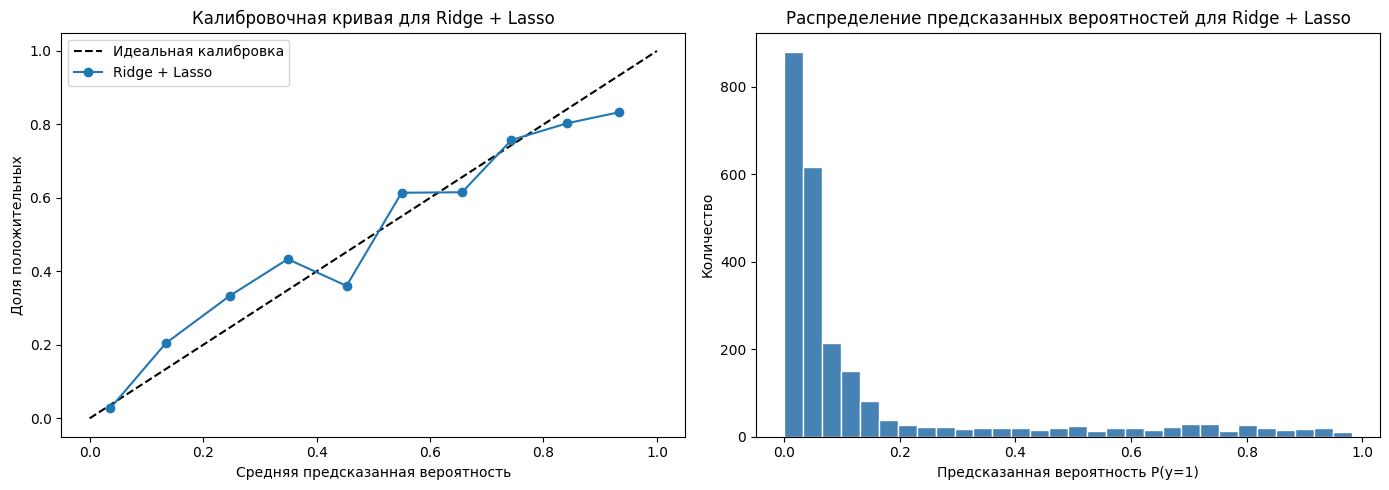

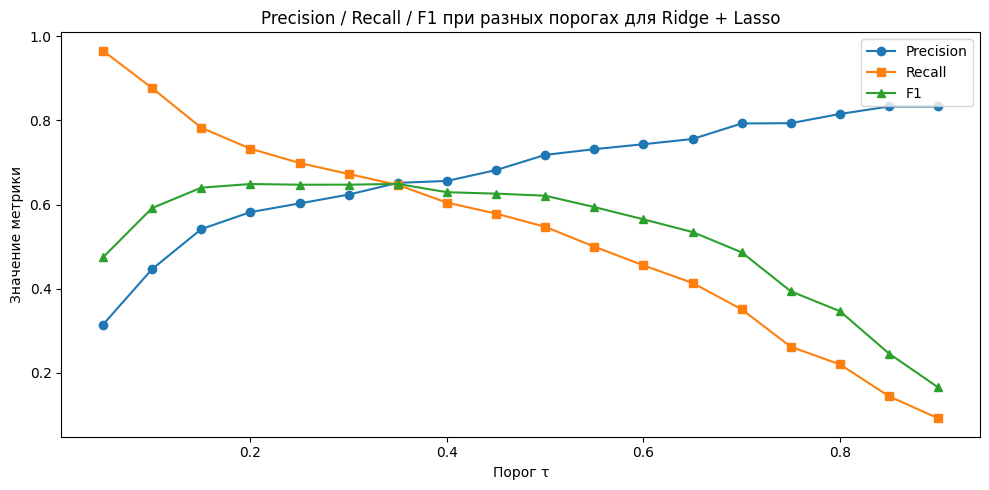

In [82]:
evaluate_classification_model(
    y_test=y_test,
    thresh=find_best_threshold(y_test=y_test, y_prob=grid_search_ridge_lasso.best_estimator_.predict_proba(X_test_processed)[:, 1]),
    y_prob=grid_search_ridge_lasso.best_estimator_.predict_proba(X_test_processed)[:, 1],
    model_name="Ridge + Lasso"
)

In [83]:
feature_names = grid_search_ridge_lasso.best_estimator_.named_steps[
    "preprocessor"
].get_feature_names_out()

coef_l1 = grid_search_ridge_lasso.best_estimator_.named_steps[
    "classifier"
].coef_[0]

selected_l1 = (coef_l1 != 0).sum()

print(f"Всего признаков: {len(feature_names)}")
print(f"Используется после L1: {selected_l1}")

Всего признаков: 62
Используется после L1: 19


In [84]:
preprocessor_feature_names = grid_search_ridge_lasso.best_estimator_.named_steps['preprocessor'].get_feature_names_out()
selected_features = grid_search_ridge_lasso.best_estimator_.named_steps['selection'].get_feature_names_out()

actual_selected_feature_names = []
for x_feature in selected_features:
    # Extract the numerical index from 'xN'
    idx = int(x_feature[1:])  # x_feature[0] is 'x', so we slice from index 1
    if idx < len(preprocessor_feature_names):
        actual_selected_feature_names.append(preprocessor_feature_names[idx])
    else:
        actual_selected_feature_names.append(f"Feature index {idx} out of bounds")

print("Actual names of selected features:")
for feature_name in actual_selected_feature_names:
    print(f"- {feature_name}")

Actual names of selected features:
- cat__OperatingSystems_3
- cat__Browser_2
- cat__TrafficType_13
- cat__TrafficType_2
- cat__TrafficType_3
- cat__TrafficType_8
- cat__VisitorType_Returning_Visitor
- cat__Month_Dec
- cat__Month_Mar
- cat__Month_May
- cat__Month_Nov
- cat__Weekend_True
- log__PageValues
- log__ProductRelated
- num__Administrative
- num__Informational
- num__BounceRates
- num__ExitRates
- num__SpecialDay


Точность практически не изменилась, хотя было удалено 43 признака

# Дерево решений

In [85]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [86]:
preprocessor = ColumnTransformer(
    transformers=[
        ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one'), log_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categ_features)
    ],
    remainder='passthrough'
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=SEED, max_depth=5))
])


param_grid = {
    "classifier__criterion" : ["gini", "entropy"],
    "classifier__max_depth": [3, 5, 7, 10, None],
    "classifier__min_samples_split": [2, 5, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 5, 10],
    "classifier__ccp_alpha" : [.0, .001, .005, .01]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

In [88]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True
)

grid_search.fit(X_train_processed, y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

best_model = grid_search.best_estimator_

y_prob = best_model.predict_proba(X_test_processed)[:, 1]


Fitting 5 folds for each of 640 candidates, totalling 3200 fits
{'classifier__ccp_alpha': 0.0, 'classifier__criterion': 'gini', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 10, 'classifier__min_samples_split': 2}
0.706424047564669


0.25
### Отчет о классификации для Decision Tree:

              precision    recall  f1-score   support

       False       0.94      0.93      0.93      2084
        True       0.63      0.70      0.67       382

    accuracy                           0.89      2466
   macro avg       0.79      0.81      0.80      2466
weighted avg       0.90      0.89      0.89      2466

### ROC-AUC для Decision Tree: 0.9175354985880958
### PR-AUC для Decision Tree: 0.6855014976525181

### Матрица ошибок для Decision Tree:



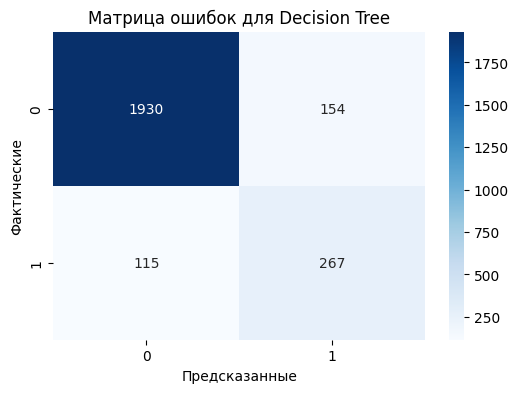

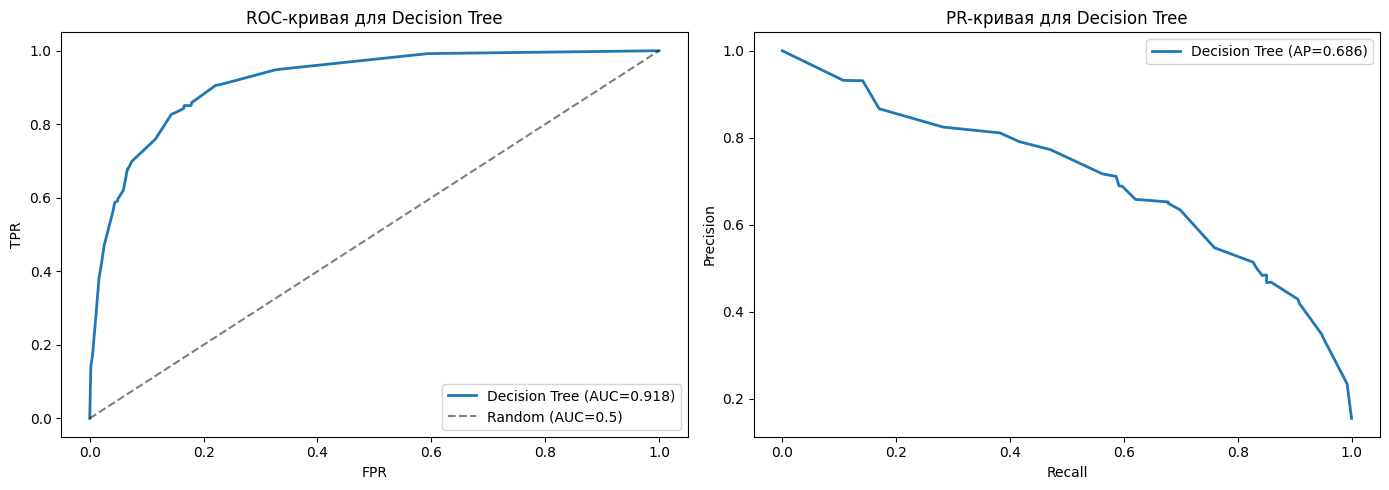

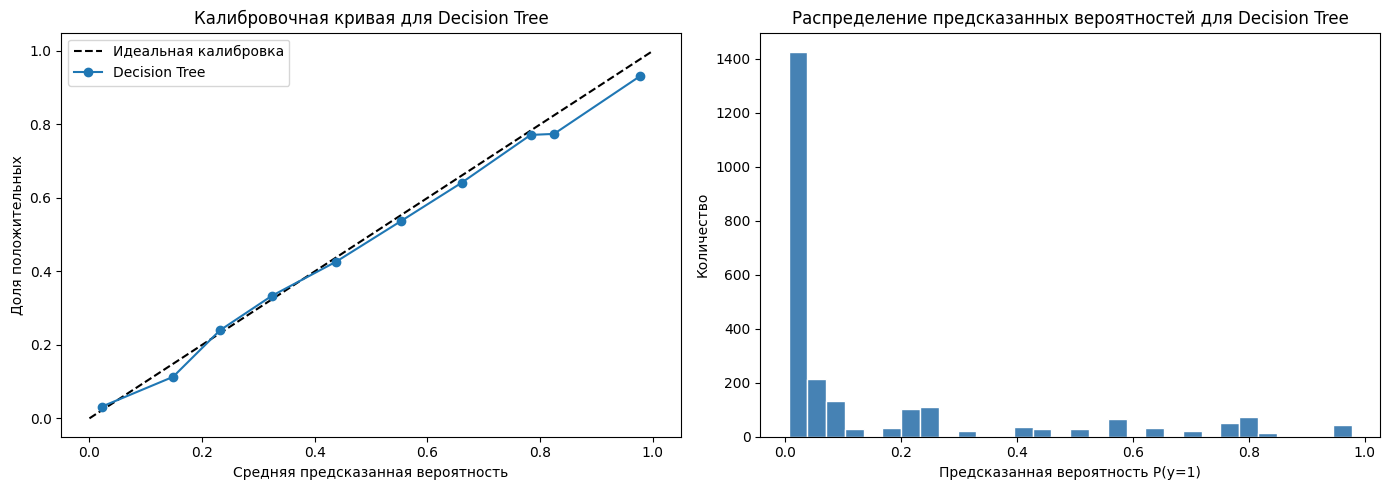

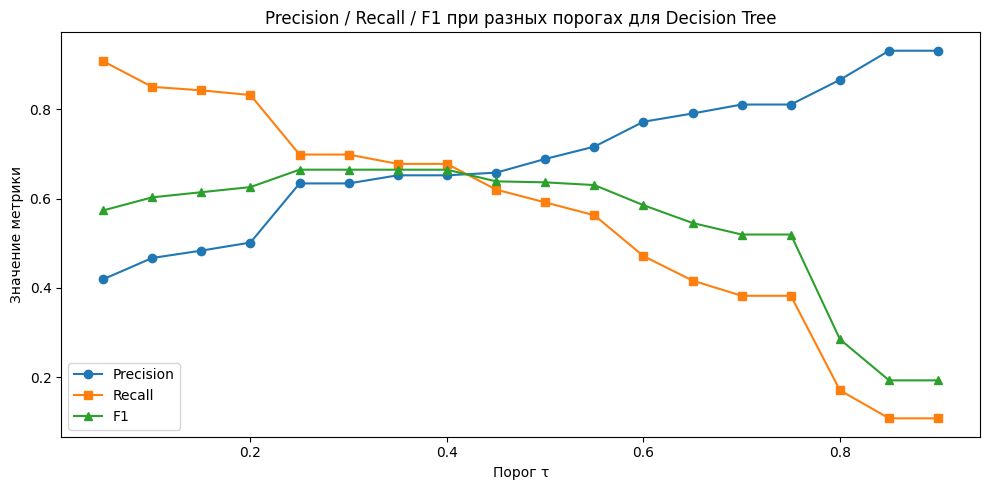

In [89]:
thresh = find_best_threshold(y_test=y_test, y_prob=y_prob)
print(thresh)
evaluate_classification_model(y_test, thresh, y_prob, model_name="Decision Tree")

In [94]:
importances = best_model.named_steps['classifier'].feature_importances_
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Визуализируем результат
display(feature_importance_df)

,Feature,Importance
0,log__PageValues,0.784345
66,remainder__BounceRates,0.074743
59,cat__Month_Nov,0.037371
1,log__ProductRelated_Duration,0.033825
64,remainder__Administrative,0.023307
...,...,...
56,cat__Month_June,0.000000
63,cat__Weekend_True,0.000000
62,cat__Weekend_False,0.000000
65,remainder__Informational,0.000000


# Логистическая регрессия

In [90]:
from sklearn.linear_model import LogisticRegression

In [95]:
quant_without_log = [f for f in quant_features if f not in log_features]
quant_without_log

['Administrative', 'Informational', 'BounceRates', 'ExitRates', 'SpecialDay']

In [98]:
log_transformer = Pipeline([
    ("log", FunctionTransformer(np.log1p, feature_names_out='one-to-one', validate=False)),
    ("scaler", StandardScaler())
])

num_transformer = Pipeline([
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            categ_features
        ),
        (
            "log",
            log_transformer,
            log_features
        ),
        (
            "num",
            num_transformer,
            quant_without_log
        )
    ]
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        random_state=42,
        max_iter=3000
    ))
])

param_grid = [
    {
        "classifier__solver": ["liblinear"],
        "classifier__penalty": ["l1", "l2"],
        "classifier__C": [0.01, 0.1, 1, 10, 100],
        "classifier__class_weight": [None, "balanced"]
    },
    {
        "classifier__solver": ["lbfgs"],
        "classifier__penalty": ["l2"],
        "classifier__C": [0.01, 0.1, 1, 10, 100],
        "classifier__class_weight": [None, "balanced"]
    }
]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True
)

grid_search.fit(X_train_processed, y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

best_model = grid_search.best_estimator_

y_prob = best_model.predict_proba(X_test_processed)[:,1]

Fitting 5 folds for each of 30 candidates, totalling 150 fits
{'classifier__C': 0.1, 'classifier__class_weight': None, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
0.6935056150720337


0.35000000000000003
### Отчет о классификации для Logistic Regression:

              precision    recall  f1-score   support

       False       0.94      0.94      0.94      2084
        True       0.65      0.65      0.65       382

    accuracy                           0.89      2466
   macro avg       0.79      0.79      0.79      2466
weighted avg       0.89      0.89      0.89      2466

### ROC-AUC для Logistic Regression: 0.9127244726713629
### PR-AUC для Logistic Regression: 0.6683170924475005

### Матрица ошибок для Logistic Regression:



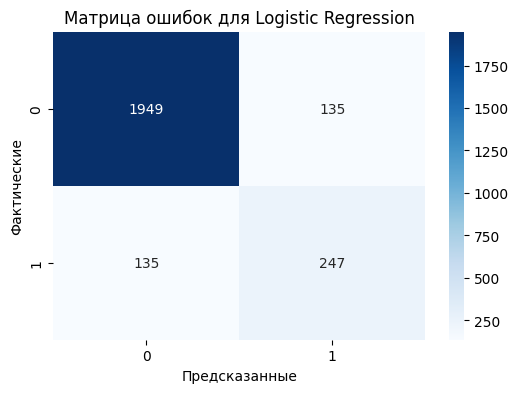

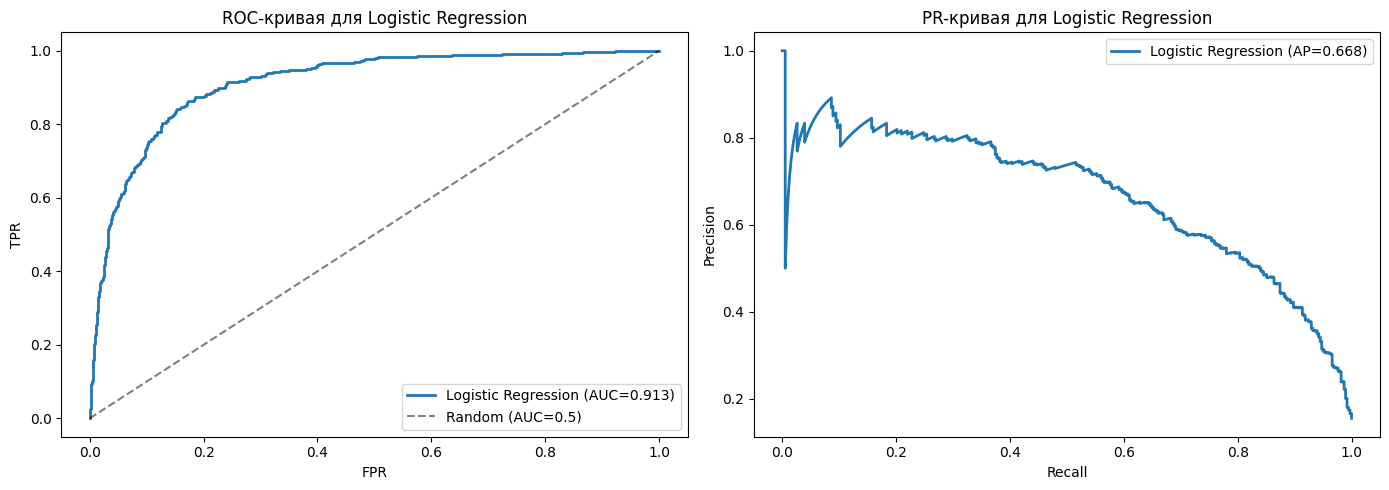

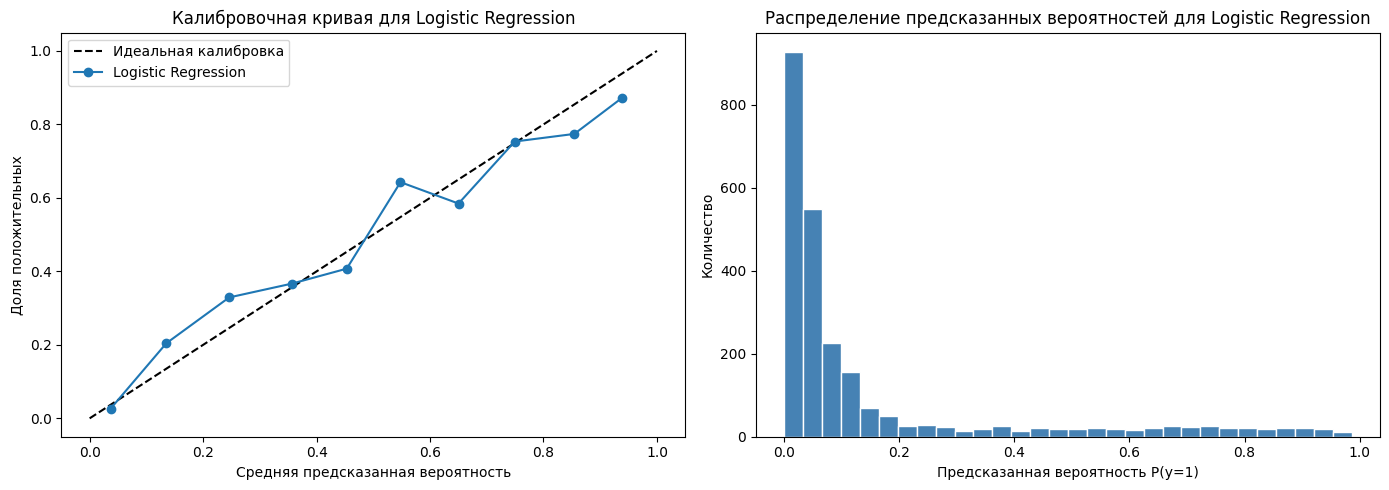

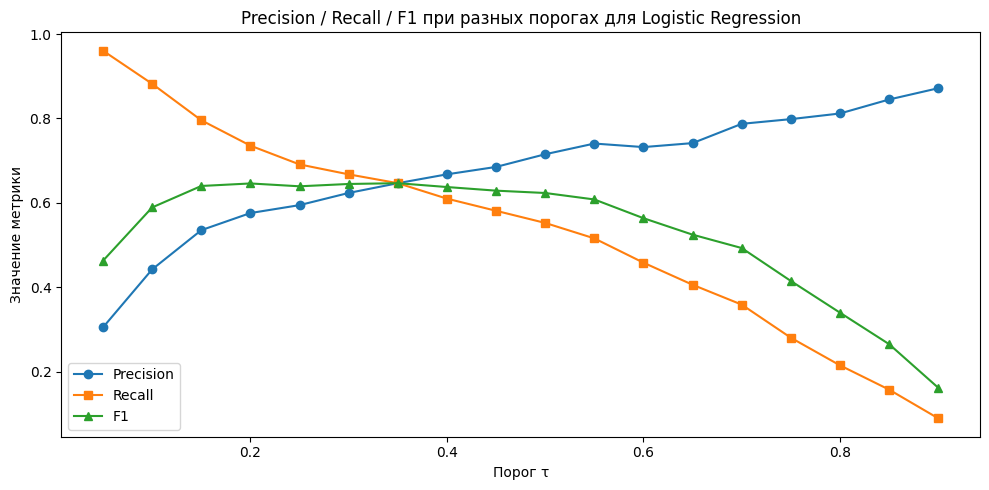

In [99]:
thresh = find_best_threshold(y_test=y_test, y_prob=y_prob)
print(thresh)
evaluate_classification_model(y_test, thresh, y_prob, model_name="Logistic Regression")

In [100]:
feature_names_lr = grid_search.best_estimator_.named_steps['preprocessor'].get_feature_names_out()
coefficients_lr = grid_search.best_estimator_.named_steps['classifier'].coef_[0]

# Create a DataFrame for better visualization
feature_importance_lr_df = pd.DataFrame({
    'Feature': feature_names_lr,
    'Coefficient': coefficients_lr,
    'Absolute_Coefficient': np.abs(coefficients_lr)
})

# Sort by absolute coefficient value to find the most significant features
feature_importance_lr_df = feature_importance_lr_df.sort_values(by='Absolute_Coefficient', ascending=False)

print("Most significant features for Logistic Regression (sorted by absolute coefficient):")
display(feature_importance_lr_df)

Most significant features for Logistic Regression (sorted by absolute coefficient):


,Feature,Coefficient,Absolute_Coefficient
52,log__PageValues,1.402217,1.402217
47,cat__Month_May,-0.657327,0.657327
41,cat__VisitorType_Returning_Visitor,-0.617092,0.617092
42,cat__Month_Dec,-0.542357,0.542357
46,cat__Month_Mar,-0.522932,0.522932
...,...,...,...
38,cat__TrafficType_9,0.012810,0.012810
29,cat__TrafficType_19,-0.011864,0.011864
56,log__Informational_Duration,-0.009619,0.009619
0,cat__OperatingSystems_2,0.009608,0.009608
